# 🚖 Uber Mobility Insights | Exploratory Data Analysis (EDA) using Python

## 📖 Project Overview

This project analyzes Uber trip data to uncover customer travel patterns, trip purposes, route popularity and business insights using Python.

The analysis applies Exploratory Data Analysis (EDA) techniques using **Pandas, NumPy, Matplotlib and Seaborn** to identify meaningful trends that support operational and business decision-making.

---
### 📌 Project Information

- **Project Type:** Exploratory Data Analysis (EDA)
- **Programming Language:** Python
- **Dataset:** Uber Drive Dataset
- **IDE:** Visual Studio Code (Jupyter Notebook)
---

## 🎯 Business Problem

Uber completes thousands of trips every day. Understanding how customers travel, why they travel and which routes are most popular can help improve service planning and business decision-making.

This project answers key business questions related to:
- Trip categories
- Trip purposes
- Popular routes
- Frequently visited locations
- Distance travelled
- Customer travel behavior

---

## 🛠️ Tools & Technologies

- **Programming Language:** Python
- **Libraries:** Pandas, NumPy, Matplotlib, Seaborn
- **Development Environment:** Jupyter Notebook (VS Code)

---

## 📊 Analysis Workflow

1. Import Required Libraries
2. Load the Dataset
3. Understand the Dataset
4. Clean and Prepare the Data
5. Perform Exploratory Data Analysis (EDA)
6. Generate Visualizations
7. Derive Business Insights & Conclusions

# 📦 Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 📂 Dataset Loading

In [58]:
uber_df = pd.read_csv("uberdrive.csv")

# 🔍 Dataset Understanding

### Q1. Display the First 10 Records

In [9]:
uber_df.head(10)

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
5,01-06-2016 17:15,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain
6,01-06-2016 17:30,01-06-2016 17:35,Business,West Palm Beach,Palm Beach,7.1,Meeting
7,01-07-2016 13:27,01-07-2016 13:33,Business,Cary,Cary,0.8,Meeting
8,01-10-2016 08:05,01-10-2016 08:25,Business,Cary,Morrisville,8.3,Meeting
9,01-10-2016 12:17,01-10-2016 12:44,Business,Jamaica,New York,16.5,Customer Visit


**Observation**

The `head(10)` function displays the first 10 records of the Uber dataset, providing an initial understanding of the dataset's structure, column names, and sample values. It also helps verify that the dataset has been loaded correctly before proceeding with further analysis.

### Q2. Display the Last 10 Records

In [10]:
uber_df.tail(10)

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
1146,12/30/2016 11:31,12/30/2016 11:56,Business,Karachi,Karachi,2.9,Errand/Supplies
1147,12/30/2016 15:41,12/30/2016 16:03,Business,Karachi,Karachi,4.6,Errand/Supplies
1148,12/30/2016 16:45,12/30/2016 17:08,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Karachi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site
1155,Totals,NaN,NaN,NaN,NaN,12204.7,NaN


**Observation**

The `tail(10)` function displays the last 10 records of the dataset, allowing us to verify the ending entries and confirm that the dataset has been loaded completely. It also helps identify any unusual values or summary rows near the end of the dataset.

### Q3. Determine the Dataset Dimensions

In [11]:
uber_df.shape

(1156, 7)

**Observation**

The dataset contains **1,156 rows** and **7 columns**, indicating a moderate-sized dataset suitable for exploratory data analysis. Each row represents an individual Uber trip, while the columns capture essential trip information such as trip timings, category, start and stop locations, distance travelled and trip purpose.

### Q4. Determine the Dataset Size

In [12]:
uber_df.size

8092

**Observation**

The dataset contains **8,092 data values** (1,156 rows × 7 columns). This confirms the overall volume of information available for analysis and helps estimate the dataset's scale before performing further exploration.

### Q5. Display Dataset Information

In [13]:
uber_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1156 non-null   object 
 1   END_DATE*    1155 non-null   object 
 2   CATEGORY*    1155 non-null   object 
 3   START*       1155 non-null   object 
 4   STOP*        1155 non-null   object 
 5   MILES*       1156 non-null   float64
 6   PURPOSE*     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


**Observation**

The dataset consists of **7 columns**, including both numerical and categorical variables. The `START_DATE*` and `END_DATE*` columns are currently stored as object data types and will require conversion to datetime format during data preparation. The output also reveals missing values in the `PURPOSE*` column, indicating that data cleaning will be necessary before performing detailed analysis.

# 🧹 Data Cleaning & Preparation

### Q6. Check if the Dataset Contains Missing Values

In [14]:
uber_df.isnull().values.any()

np.True_

**Observation**

The output is **True**, indicating that the dataset contains missing values. Before proceeding with analysis, it is important to identify which columns contain these missing values and handle them appropriately.

### Q7. Count Missing Values in Each Column

In [15]:
uber_df.isnull().sum()

START_DATE*      0
END_DATE*        1
CATEGORY*        1
START*           1
STOP*            1
MILES*           0
PURPOSE*       503
dtype: int64

**Observation**

The **PURPOSE*** column contains the highest number of missing values (**503**). Additionally, **END_DATE***, **CATEGORY***, **START***, and **STOP*** each contain **1** missing value, while **START_DATE*** and **MILES*** have no missing values. These missing values need to be handled before performing further analysis.

### Q8. Remove Missing Values

In [16]:
uber_df.dropna(inplace=True)

**Observation**

Rows containing missing values have been removed from the dataset using the `dropna()` function. This ensures that the remaining dataset is complete and suitable for accurate analysis.

### Q9. Verify Missing Values After Cleaning

In [17]:
uber_df.isnull().sum()

START_DATE*    0
END_DATE*      0
CATEGORY*      0
START*         0
STOP*          0
MILES*         0
PURPOSE*       0
dtype: int64

**Observation**

The output shows **zero missing values** across all columns, confirming that the dataset has been successfully cleaned and is ready for further analysis.

### Q10. Check for Duplicate Records

In [19]:
uber_df.duplicated().sum()

np.int64(1)

**Observation**

This step checks for duplicate records in the dataset. Duplicate entries can lead to inaccurate analysis and should be removed to ensure each Uber trip is represented only once.

# 📈 Exploratory Data Analysis (EDA)

### Q11. Get Unique Start Locations

In [21]:
un_start_destination = uber_df["START*"].dropna()
unique_start = set(un_start_destination)
unique_start

{'Apex',
 'Arabi',
 'Asheville',
 'Austin',
 'Banner Elk',
 'Bellevue',
 'Berkeley',
 'Boone',
 'Briar Meadow',
 'Burtrose',
 'CBD',
 'Capitol One',
 'Cary',
 'Chalmette',
 'Chapel Hill',
 'Chessington',
 'Colombo',
 'Daytona Beach',
 'Downtown',
 'Durham',
 'Eagan Park',
 'East Austin',
 'East Elmhurst',
 'East Harlem',
 'Eastgate',
 'Edgehill Farms',
 'El Cerrito',
 'Elmhurst',
 'Emeryville',
 'Fairmont',
 'Farmington Woods',
 'Fayetteville Street',
 'Financial District',
 'Flatiron District',
 'Florence',
 'Fort Pierce',
 'Fuquay-Varina',
 'Galveston',
 'Gampaha',
 'Georgian Acres',
 'Gulfton',
 'Hazelwood',
 "Hell's Kitchen",
 'Heritage Pines',
 'Holly Springs',
 'Houston',
 'Hudson Square',
 'Huntington Woods',
 'Ingleside',
 'Islamabad',
 'Jacksonville',
 'Jamaica',
 'Karachi',
 'Katunayaka',
 'Katunayake',
 'Katy',
 'Kenner',
 'Kilarney Woods',
 'Kissimmee',
 'Krendle Woods',
 'Lahore',
 'Lake Reams',
 'Lake Wellingborough',
 'Latta',
 'Lexington Park at Amberly',
 'Long Island 

**Observation**

This analysis identifies all unique starting locations from where Uber trips began. Converting the values into a set removes duplicate locations, providing the distinct pickup locations available in the dataset.

### Q12. Count the Total Number of Unique Start Locations

In [23]:
len(unique_start)

131

**Observation**

The output represents the total number of unique pickup locations in the dataset. This helps understand the geographical spread of Uber trip origins.

### Q13. Get Unique Stop Locations

In [24]:
stop_destination = uber_df["STOP*"].dropna()
unique_stop = set(stop_destination)
unique_stop

{'Agnew',
 'Alief',
 'Apex',
 'Arabi',
 'Asheville',
 'Banner Elk',
 'Bay Farm Island',
 'Bellevue',
 'Berkeley',
 'Boone',
 'Burtrose',
 'Capitol One',
 'Cary',
 'Cedar Hill',
 'Chalmette',
 'Chapel Hill',
 'Chessington',
 'Colombo',
 'Congress Ave District',
 'Convention Center District',
 'Coxville',
 'Daytona Beach',
 'Depot Historic District',
 'Downtown',
 'Durham',
 'East Harlem',
 'Edgehill Farms',
 'El Cerrito',
 'Emeryville',
 'Faubourg Marigny',
 'Financial District',
 'Florence',
 'Fort Pierce',
 'Fuquay-Varina',
 'Galveston',
 'Gampaha',
 'Gramercy-Flatiron',
 'Greater Greenspoint',
 'Gulfton',
 'Harden Place',
 'Hayesville',
 'Hazelwood',
 "Hell's Kitchen",
 'Heritage Pines',
 'Hog Island',
 'Holly Springs',
 'Houston',
 'Hudson Square',
 'Ilukwatta',
 'Islamabad',
 'Jacksonville',
 'Jamaica',
 'Jamestown Court',
 'Karachi',
 'Katunayaka',
 'Katy',
 'Kenner',
 'Kildaire Farms',
 'Kips Bay',
 'Kissimmee',
 'Lahore',
 'Lake Reams',
 'Lakeview',
 'Latta',
 'Leesville Hollow'

**Observation**

This analysis retrieves all distinct destination locations where Uber trips ended. Using a set removes duplicate values, making it easier to identify all unique drop-off points.

### Q14. Count the Total Number of Unique Stop Locations

In [25]:
len(unique_stop)

137

**Observation**

The output represents the total number of unique drop-off locations in the dataset. Comparing this with the number of unique pickup locations helps understand the overall coverage of Uber trips.

### Q15. Display All Uber Trips Starting from San Francisco

In [26]:
uber_df[uber_df["START*"] == "San Francisco"]

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
362,05-09-2016 14:39,05-09-2016 15:06,Business,San Francisco,Palo Alto,20.5,Between Offices
440,6/14/2016 16:09,6/14/2016 16:39,Business,San Francisco,Emeryville,11.6,Meeting
917,11-07-2016 19:17,11-07-2016 19:57,Business,San Francisco,Berkeley,13.2,Between Offices
919,11-08-2016 12:16,11-08-2016 12:49,Business,San Francisco,Berkeley,11.3,Meeting
927,11-09-2016 18:40,11-09-2016 19:17,Business,San Francisco,Oakland,12.7,Customer Visit
933,11-10-2016 15:17,11-10-2016 15:22,Business,San Francisco,Oakland,9.9,Temporary Site
966,11/15/2016 20:44,11/15/2016 21:00,Business,San Francisco,Berkeley,11.8,Temporary Site


**Observation**

This query retrieves all Uber trips that originated from **San Francisco**. Analyzing trips from a specific location helps understand travel patterns, customer demand, and frequently visited destinations from that city.

### Q16. Count the Number of Trips Starting from San Francisco

In [27]:
uber_df[uber_df["START*"] == "San Francisco"].shape[0]

7

**Observation**

The output represents the total number of Uber trips that started from **San Francisco**. This helps measure the activity level and trip frequency originating from this location.

### Q17. Display All Uber Trips Ending at San Francisco

In [28]:
uber_df[uber_df["STOP*"] == "San Francisco"]

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
367,05-11-2016 08:35,05-11-2016 09:12,Business,Newark,San Francisco,25.6,Meeting
916,11-07-2016 12:28,11-07-2016 12:57,Business,Berkeley,San Francisco,11.8,Between Offices
918,11-08-2016 10:29,11-08-2016 10:57,Business,Berkeley,San Francisco,12.2,Between Offices
930,11-10-2016 09:46,11-10-2016 10:15,Business,Berkeley,San Francisco,12.6,Temporary Site
965,11/15/2016 14:09,11/15/2016 14:26,Business,Oakland,San Francisco,9.7,Temporary Site


**Observation**

This query retrieves all Uber trips that ended at **San Francisco**. Examining destination-specific trips helps identify popular drop-off locations and travel demand.

### Q18. Count the Number of Trips Ending at San Francisco

In [29]:
uber_df[uber_df["STOP*"] == "San Francisco"].shape[0]

5

**Observation**

The output shows the total number of Uber trips that ended in **San Francisco**, providing insight into the city's importance as a destination within the dataset.

### Q19. Find the Most Frequent Start Location

In [30]:
uber_df["START*"].value_counts().head(1)

START*
Cary    161
Name: count, dtype: int64

**Observation**

This analysis identifies the **most frequently used pickup location** in the dataset. It helps determine the area with the highest trip origin, which can indicate high customer demand or business activity.

### Q20. Find the Most Frequent Stop Location

In [31]:
uber_df["STOP*"].value_counts().head(1)

STOP*
Cary    155
Name: count, dtype: int64

**Observation**

This analysis identifies the **most frequently visited drop-off location**. Understanding the most common destination helps reveal popular travel patterns and customer preferences.

### Q21. Find the Most Frequent Route (Start → Stop)

In [32]:
uber_df.groupby(["START*", "STOP*"]).size().sort_values(ascending=False).head(1)

START*  STOP*      
Cary    Morrisville    52
dtype: int64

**Observation**

This analysis identifies the **most frequently travelled route** by combining the pickup and drop-off locations. It helps understand common travel patterns and frequently used routes within the dataset.

### Q22. Analyze Business vs Personal Trips

In [33]:
uber_df["CATEGORY*"].value_counts()

CATEGORY*
Business    647
Personal      6
Name: count, dtype: int64

**Observation**

This analysis compares the distribution of **Business and Personal** trips. Understanding the proportion of each category helps identify the primary purpose of Uber usage within the dataset.

### Q23. Calculate the Percentage of Business and Personal Trips

In [34]:
(uber_df["CATEGORY*"].value_counts(normalize=True) * 100).round(2)

CATEGORY*
Business    99.08
Personal     0.92
Name: proportion, dtype: float64

**Observation**

This analysis calculates the percentage distribution of **Business and Personal trips**. Expressing the results as percentages provides a clearer understanding of customer travel behavior than raw counts alone.

### Q24. Find the Most Common Trip Purpose

In [35]:
uber_df["PURPOSE*"].value_counts().head(1)

PURPOSE*
Meeting    187
Name: count, dtype: int64

**Observation**

This analysis identifies the **most common purpose** for Uber trips in the dataset. Understanding trip purposes helps reveal customer travel behavior and the primary reasons for using Uber services.

### Q25. Display the Distribution of All Trip Purposes

In [36]:
uber_df["PURPOSE*"].value_counts()

PURPOSE*
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Commute              1
Charity ($)          1
Name: count, dtype: int64

**Observation**

The output displays the **frequency** of each trip purpose, helping identify the most and least common reasons for travel. These insights can support customer behavior analysis and service planning.

### Q26. Find the Longest Uber Trip

In [38]:
uber_df.loc[uber_df["MILES*"].idxmax()]

START_DATE*    3/25/2016 16:52
END_DATE*      3/25/2016 22:22
CATEGORY*             Business
START*                   Latta
STOP*             Jacksonville
MILES*                   310.3
PURPOSE*        Customer Visit
Name: 269, dtype: object

**Observation**

This analysis identifies the **trip with the maximum travel distance**. It helps understand exceptional travel patterns and long-distance usage within the dataset.

### Q27. Find the Average Distance Travelled per Trip

In [39]:
uber_df["MILES*"].mean()

np.float64(11.196324655436449)

**Observation**

The **average trip distance** provides an overall measure of customer travel behavior and helps understand the typical distance covered in an Uber trip.

### Q28. Find the Total Distance Travelled

In [40]:
uber_df["MILES*"].sum()

np.float64(7311.200000000001)

**Observation**

This analysis calculates the **total distance travelled** across all Uber trips in the dataset, providing an overall measure of travel activity.

# 📊 Data Visualization

### Q29. Visualize the Distribution of Business and Personal Trips

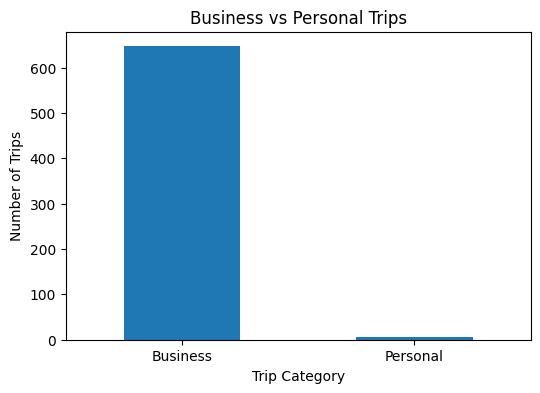

In [45]:
uber_df["CATEGORY*"].value_counts().plot(kind="bar", figsize=(6,4), title="Business vs Personal Trips")

plt.xlabel("Trip Category")
plt.ylabel("Number of Trips")
plt.xticks(rotation=0)
plt.show()

**Observation**

The chart compares the number of **Business and Personal trips**. It clearly shows which category dominates the dataset and provides a quick visual understanding of customer travel behavior.

### Q30. Visualize the Top 10 Start Locations

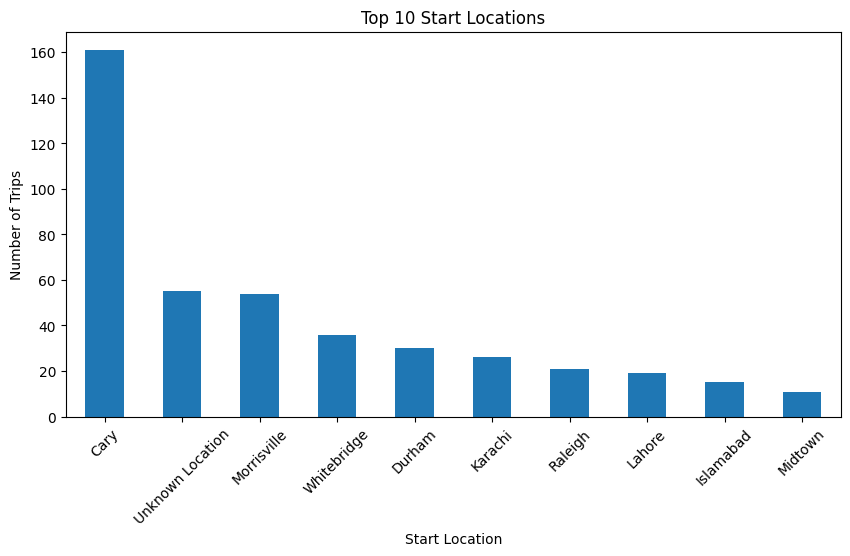

In [47]:
uber_df["START*"].value_counts().head(10).plot(kind="bar", figsize=(10,5), title="Top 10 Start Locations")

plt.xlabel("Start Location")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

**Observation**

The visualization highlights the **ten most frequent pickup locations**, helping identify areas with the highest trip demand.

### Q31. Visualize the Top 10 Stop Locations

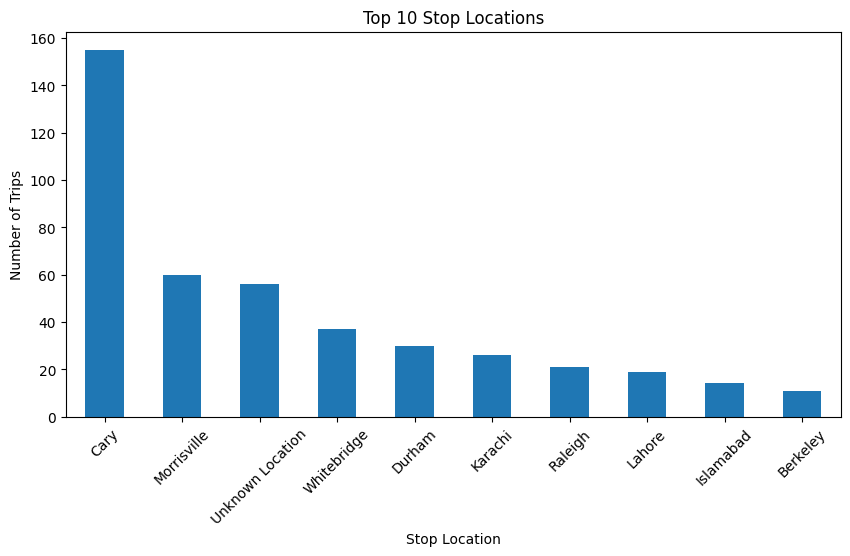

In [49]:
uber_df["STOP*"].value_counts().head(10).plot(kind="bar", figsize=(10,5), title="Top 10 Stop Locations")

plt.xlabel("Stop Location")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

**Observation**

This chart displays the **most common drop-off locations**, providing insights into customer destination preferences.

### Q32. Visualize Trip Purposes

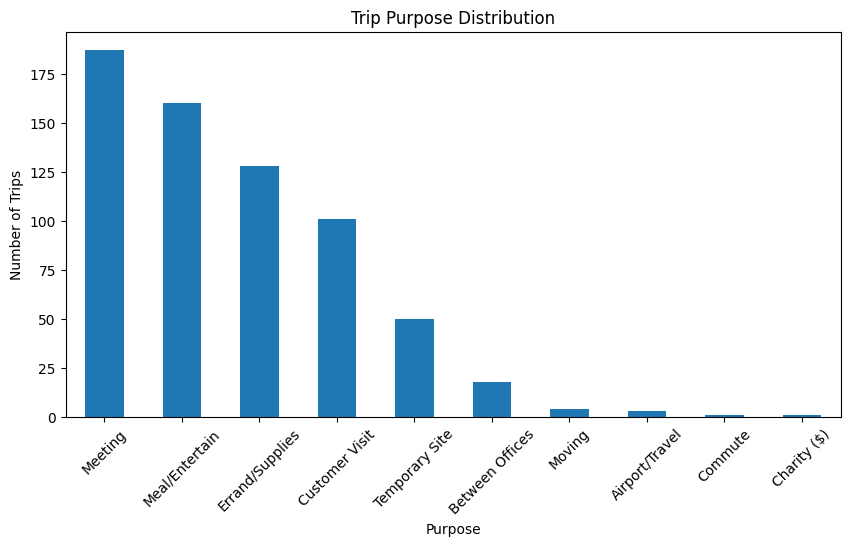

In [50]:
uber_df["PURPOSE*"].value_counts().plot(kind="bar", figsize=(10,5), title="Trip Purpose Distribution")

plt.xlabel("Purpose")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

**Observation**

The chart illustrates the **frequency of different trip purposes**, helping identify the primary reasons customers use Uber.

### Q33. Visualize the Distribution of Trip Distance

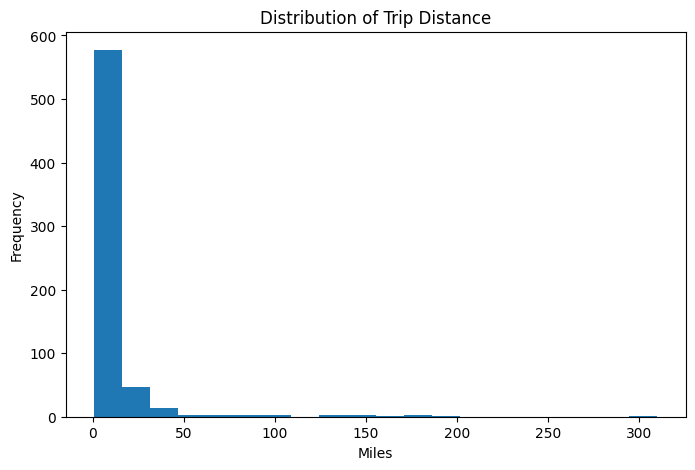

In [53]:
uber_df["MILES*"].plot(kind="hist", bins=20, figsize=(8,5), title="Distribution of Trip Distance")

plt.xlabel("Miles")
plt.ylabel("Frequency")
plt.show()

**Observation**

The histogram shows how **trip distances are distributed**. It helps identify whether most trips are short-distance or long-distance journeys.

# 🎨 Advanced Data Visualization using Seaborn

### Q34. Visualize the Distribution of Trip Distances using Seaborn

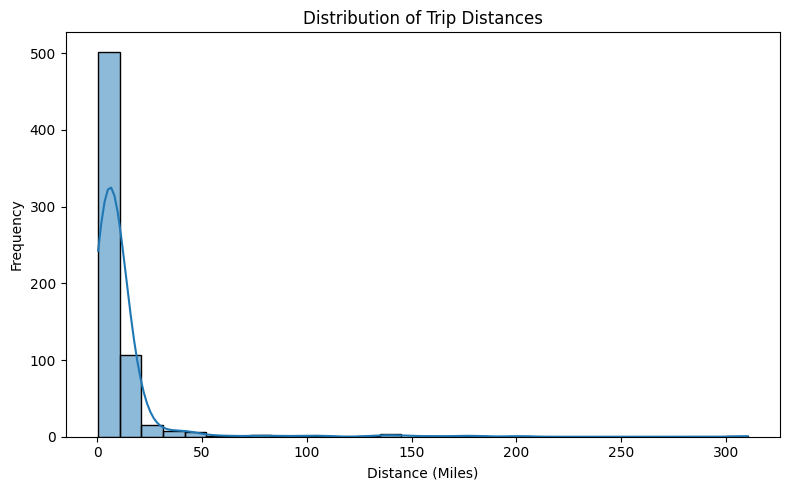

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(data=uber_df, x="MILES*", bins=30, kde=True)

plt.title("Distribution of Trip Distances")
plt.xlabel("Distance (Miles)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Observation**

The histogram shows that most Uber trips are short-distance journeys, while only a few trips cover long distances. The KDE curve highlights the overall distribution pattern of trip distances.

### Q35. Compare Trip Distance Across Business and Personal Categories

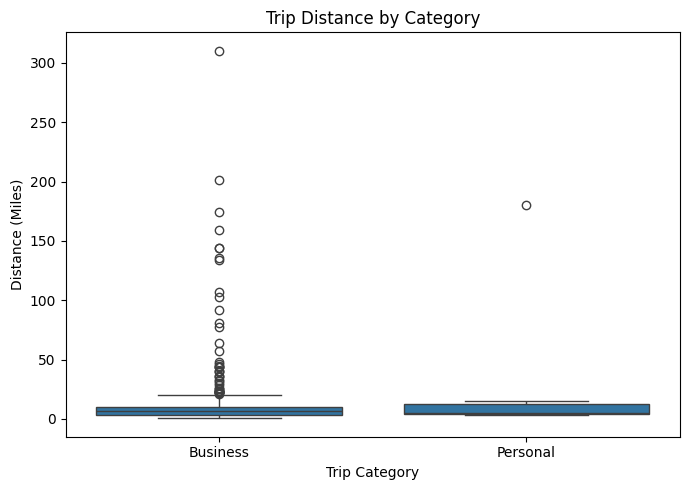

In [55]:
plt.figure(figsize=(7,5))

sns.boxplot(data=uber_df, x="CATEGORY*", y="MILES*")

plt.title("Trip Distance by Category")
plt.xlabel("Trip Category")
plt.ylabel("Distance (Miles)")

plt.tight_layout()
plt.show()

**Observation**

The box plot compares the distribution of trip distances for Business and Personal trips. It highlights differences in median distance, spread, and potential outliers between the two categories.

### Q36. Visualize the Top Trip Purposes using Seaborn

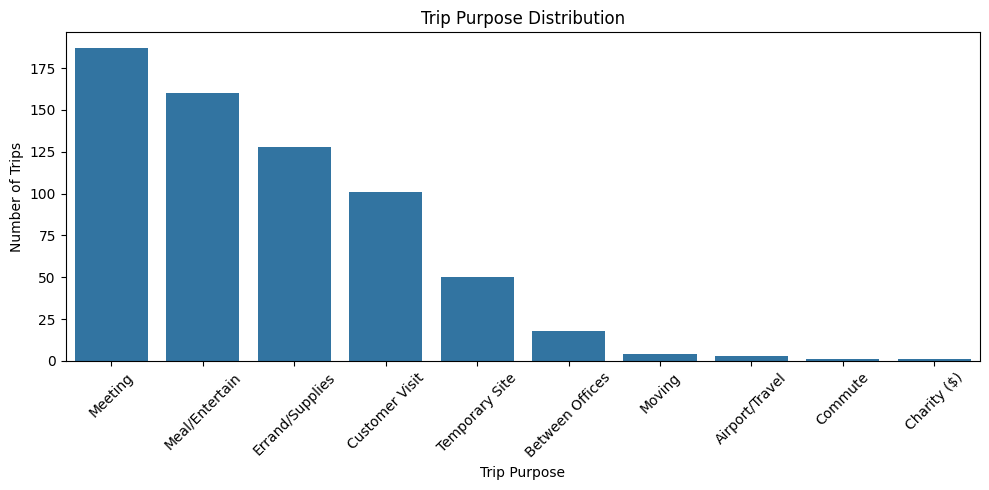

In [56]:
purpose_counts = (uber_df["PURPOSE*"].value_counts().reset_index())

purpose_counts.columns = ["Purpose", "Count"]

plt.figure(figsize=(10,5))

sns.barplot(data=purpose_counts, x="Purpose", y="Count")

plt.title("Trip Purpose Distribution")
plt.xlabel("Trip Purpose")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Observation**

The visualization highlights the frequency of different trip purposes, helping identify the most common reasons customers use Uber services. This can support business planning and customer behavior analysis.

# 💼 Business Insights

### Key Business Insights

Based on the Exploratory Data Analysis (EDA), the following business insights were identified:

- **Business trips dominate Uber usage**, accounting for the majority of all trips in the dataset.
- **Cary** is the most frequently used pickup location, indicating high travel demand from this city.
- The route **Cary → Morrisville** is the most commonly travelled route, suggesting frequent movement between these locations.
- **Meeting** is one of the most common trip purposes, highlighting the importance of Uber for business-related travel.
- Most Uber trips cover **short distances**, while only a few trips involve long-distance travel.
- The dataset shows that Uber is primarily used for **professional and business activities** rather than personal travel.

# ✅ Conclusion

### Conclusion

This project analyzed Uber trip data using **Python**, **Pandas**, **NumPy**, **Matplotlib**, and **Seaborn** to understand customer travel behavior and trip patterns.

The analysis involved:

- Data loading and exploration
- Data cleaning and preparation
- Exploratory Data Analysis (EDA)
- Statistical summaries
- Data visualization
- Business insight generation

The findings revealed that business travel accounts for the majority of Uber trips, with Cary emerging as the busiest pickup location. Most journeys were short-distance trips, and business-related purposes such as meetings dominated the travel patterns.

Overall, this project demonstrates how Python can be used to transform raw transportation data into meaningful business insights that support data-driven decision-making.

## 📚 Key Python Concepts Demonstrated

Throughout this project, the following Python concepts and libraries were applied:

- Data Loading using Pandas
- Data Cleaning
- Handling Missing Values
- Duplicate Detection and Removal
- Exploratory Data Analysis (EDA)
- GroupBy Operations
- Value Counts
- Indexing and Filtering
- Statistical Analysis
- Data Visualization using Matplotlib
- Data Visualization using Seaborn

## 🙏 Thank You

Thank you for exploring this project.

I hope you found this analysis insightful and informative.

If you have any feedback or suggestions, feel free to connect with me through GitHub or LinkedIn.

Thank you for your time!